In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sawtooth.csv")

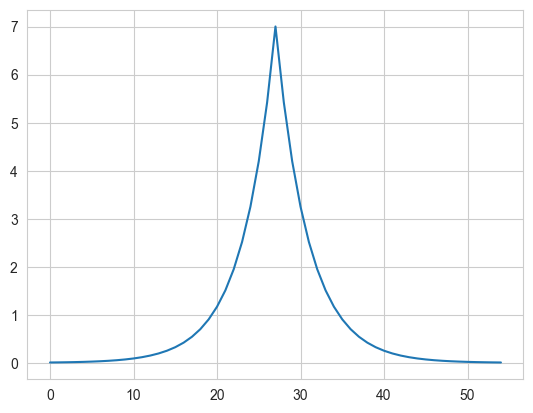

In [4]:
plt.plot(df["t"], df["f"])

In [5]:
   np.mean(df["f"]) 

1.0000000000000002

In [6]:
# Does polygenomic infectiousness change?

In [7]:
sawtooth = df["f"].values

In [8]:
np.random.choice(sawtooth)

0.116828120457376

In [2]:
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))


In [10]:
infectiousness_from_gametocytes(1e8, 20)

0.03942381321762367

In [31]:
def was_oocyst_clonal(s1_value, s2_value, s3_value, s4_value):
    # select 2, weighted by the values
    s = [s1_value, s2_value, s3_value, s4_value]
    s = np.array(s)
    s = s/sum(s)
    s = np.random.choice([0, 1, 2, 3], 2, p=s)
    
    # return True if they are the same
    return s[0] == s[1]

def oocyst_clonal_exact(s1_value, s2_value, s3_value, s4_value):
    s = [s1_value, s2_value, s3_value, s4_value]
    s = np.array(s)
    s = s/sum(s)
    return s[0]*s[0] + s[1]*s[1] + s[2]*s[2] + s[3]*s[3]

def average_was_oocyst_clonal_result(n_trials, s1_value, s2_value, s3_value, s4_value):
    return np.mean([was_oocyst_clonal(s1_value, s2_value, s3_value, s4_value) for i in range(n_trials)])

0.1136700024581173


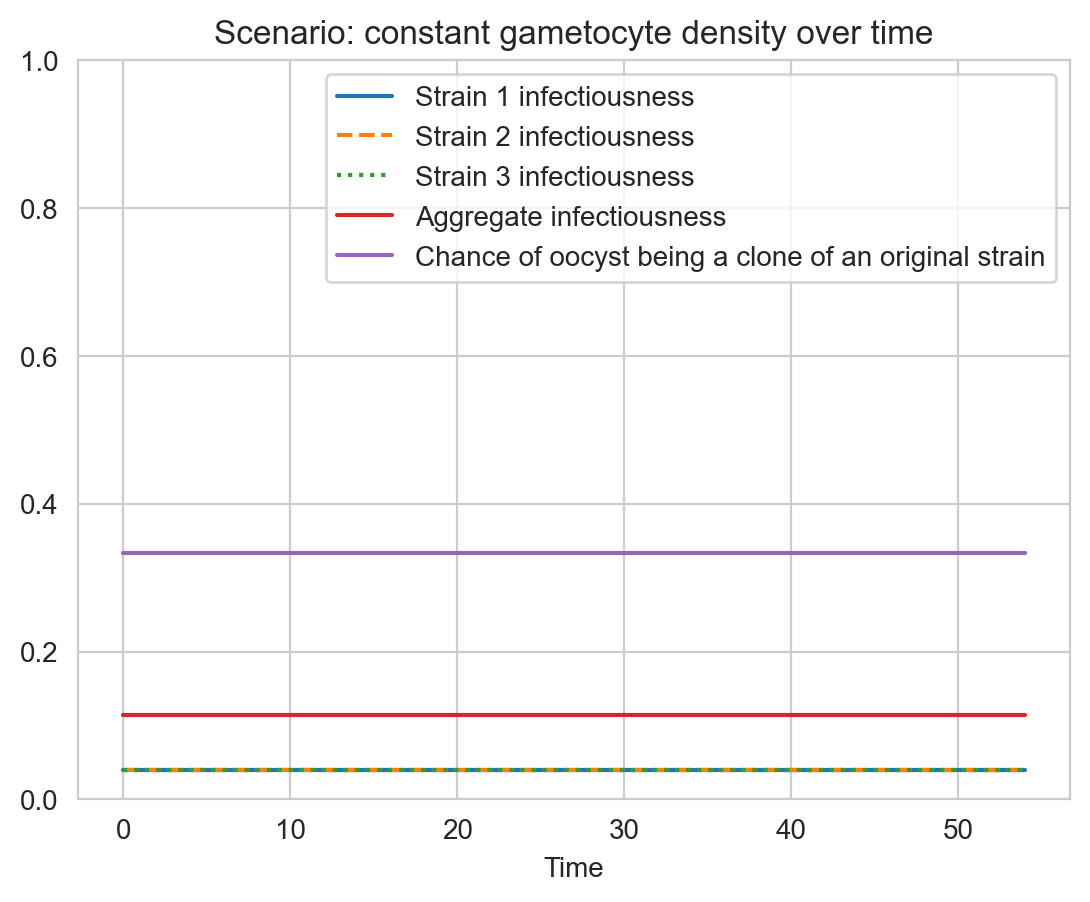

In [41]:
baseline_g_density = 1e8
n_timesteps = 55
ti = np.zeros(n_timesteps)
s1 = np.zeros(n_timesteps)
s2 = np.zeros(n_timesteps)
s3 = np.zeros(n_timesteps)
wc = np.zeros(n_timesteps)

for t in np.arange(n_timesteps):
    s1[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    s2[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    s3[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    ti[t] = 1-np.prod([1-s1[t], 1-s2[t], 1-s3[t]])
    # wc[t] = average_was_oocyst_clonal_result(1000, s1[t], s2[t], s3[t], 0)
    wc[t] = oocyst_clonal_exact(s1[t], s2[t], s3[t], 0)
    
plt.figure(dpi=200)
plt.plot(np.arange(n_timesteps), s1, label="Strain 1 infectiousness")
plt.plot(np.arange(n_timesteps), s2, label="Strain 2 infectiousness", linestyle='dashed')
plt.plot(np.arange(n_timesteps), s3, label="Strain 3 infectiousness", linestyle='dotted')
plt.plot(np.arange(n_timesteps), ti, label="Aggregate infectiousness")
plt.plot(np.arange(n_timesteps), wc, label="Chance of oocyst being a clone of an original strain")

plt.xlabel("Time")
plt.legend()
plt.title("Scenario: constant gametocyte density over time")

plt.ylim([0,1])

print(np.mean(ti))

0.11085869814047049


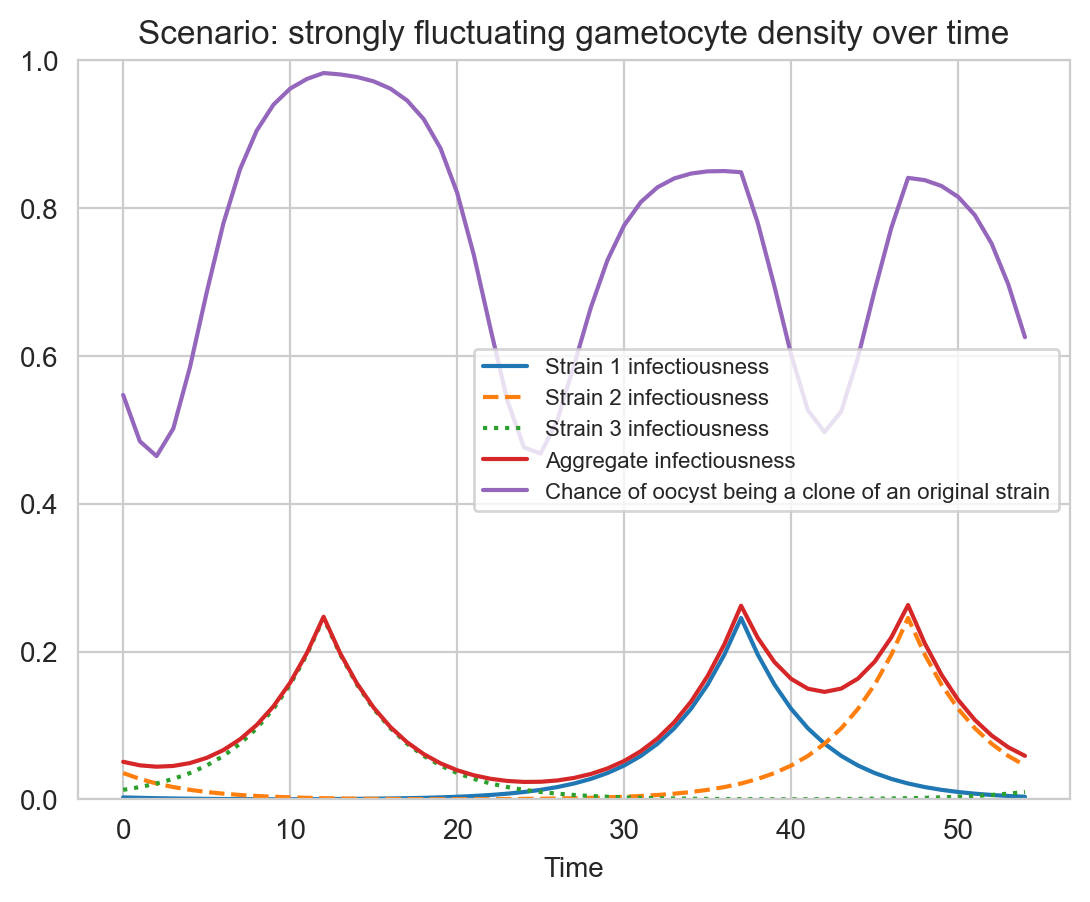

In [42]:
baseline_g_density = 1e8
n_timesteps = 55
ti = np.zeros(n_timesteps)
s1 = np.zeros(n_timesteps)
s2 = np.zeros(n_timesteps)
s3 = np.zeros(n_timesteps)
wc = np.zeros(n_timesteps)

# s1_modulator = np.roll(sawtooth, np.random.randint(55))
s1_modulator = np.roll(sawtooth, 10)
# s2_modulator = np.roll(sawtooth, np.random.randint(55))
s2_modulator = np.roll(sawtooth, 20)
# s3_modulator = np.roll(sawtooth, np.random.randint(55))
s3_modulator = np.roll(sawtooth, 40)

for t in np.arange(n_timesteps):
    s1[t] = infectiousness_from_gametocytes(baseline_g_density*s1_modulator[t], 20)
    s2[t] = infectiousness_from_gametocytes(baseline_g_density*s2_modulator[t], 20)
    s3[t] = infectiousness_from_gametocytes(baseline_g_density*s3_modulator[t], 20)
    ti[t] = 1-np.prod([1-s1[t], 1-s2[t], 1-s3[t]])
    # wc[t] = average_was_oocyst_clonal_result(1000, s1[t], s2[t], s3[t], 0)
    wc[t] = oocyst_clonal_exact(s1[t], s2[t], s3[t], 0)

plt.figure(dpi=200)
plt.plot(np.arange(n_timesteps), s1, label="Strain 1 infectiousness")
plt.plot(np.arange(n_timesteps), s2, label="Strain 2 infectiousness", linestyle='dashed')
plt.plot(np.arange(n_timesteps), s3, label="Strain 3 infectiousness", linestyle='dotted')
plt.plot(np.arange(n_timesteps), ti, label="Aggregate infectiousness")
plt.plot(np.arange(n_timesteps), wc, label="Chance of oocyst being a clone of an original strain")

plt.xlabel("Time")
plt.legend(fontsize=8)
plt.title("Scenario: strongly fluctuating gametocyte density over time")
plt.ylim([0,1])

print(np.mean(ti))

0.7008048970016864


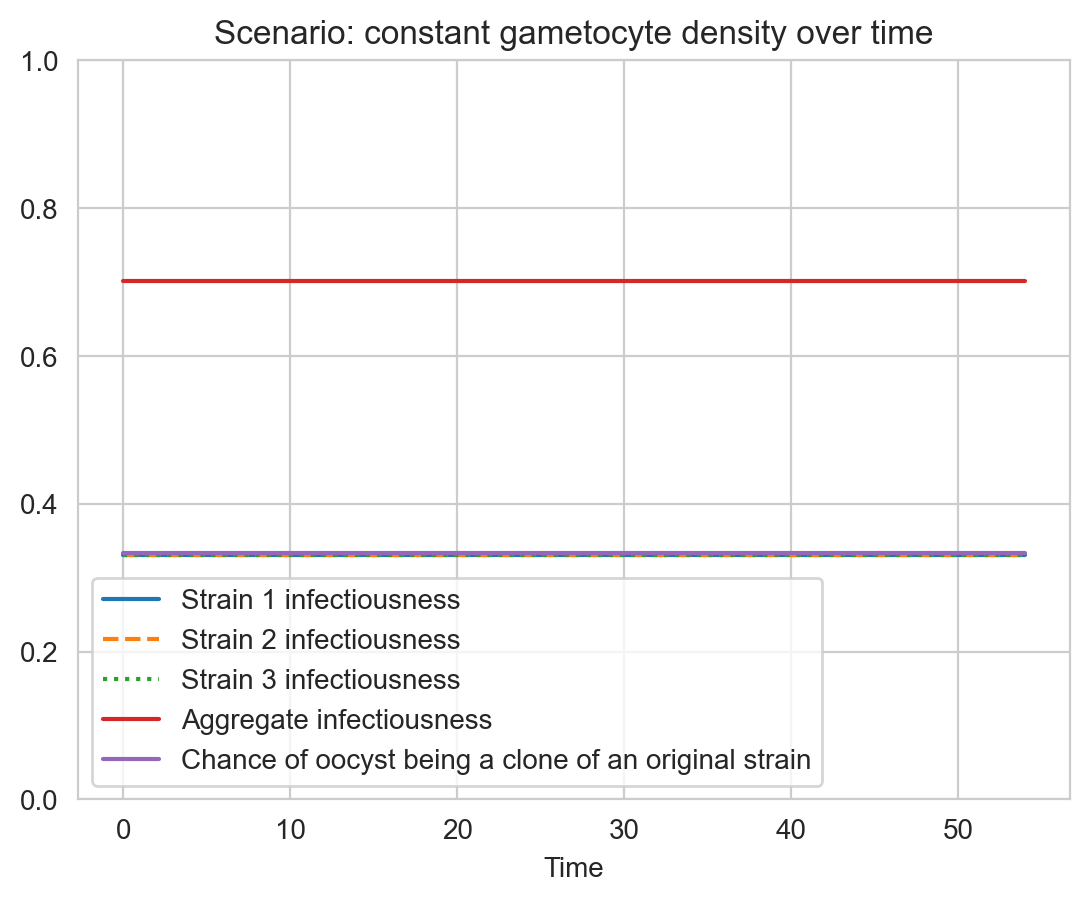

In [44]:
baseline_g_density = 1e9
n_timesteps = 55
ti = np.zeros(n_timesteps)
s1 = np.zeros(n_timesteps)
s2 = np.zeros(n_timesteps)
s3 = np.zeros(n_timesteps)
wc = np.zeros(n_timesteps)

for t in np.arange(n_timesteps):
    s1[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    s2[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    s3[t] = infectiousness_from_gametocytes(baseline_g_density, 20)
    ti[t] = 1-np.prod([1-s1[t], 1-s2[t], 1-s3[t]])
    # wc[t] = average_was_oocyst_clonal_result(1000, s1[t], s2[t], s3[t], 0)
    wc[t] = oocyst_clonal_exact(s1[t], s2[t], s3[t], 0)
    
plt.figure(dpi=200)
plt.plot(np.arange(n_timesteps), s1, label="Strain 1 infectiousness")
plt.plot(np.arange(n_timesteps), s2, label="Strain 2 infectiousness", linestyle='dashed')
plt.plot(np.arange(n_timesteps), s3, label="Strain 3 infectiousness", linestyle='dotted')
plt.plot(np.arange(n_timesteps), ti, label="Aggregate infectiousness")
plt.plot(np.arange(n_timesteps), wc, label="Chance of oocyst being a clone of an original strain")

plt.xlabel("Time")
plt.legend()
plt.title("Scenario: constant gametocyte density over time")

plt.ylim([0,1])

print(np.mean(ti))

0.6104750206611192


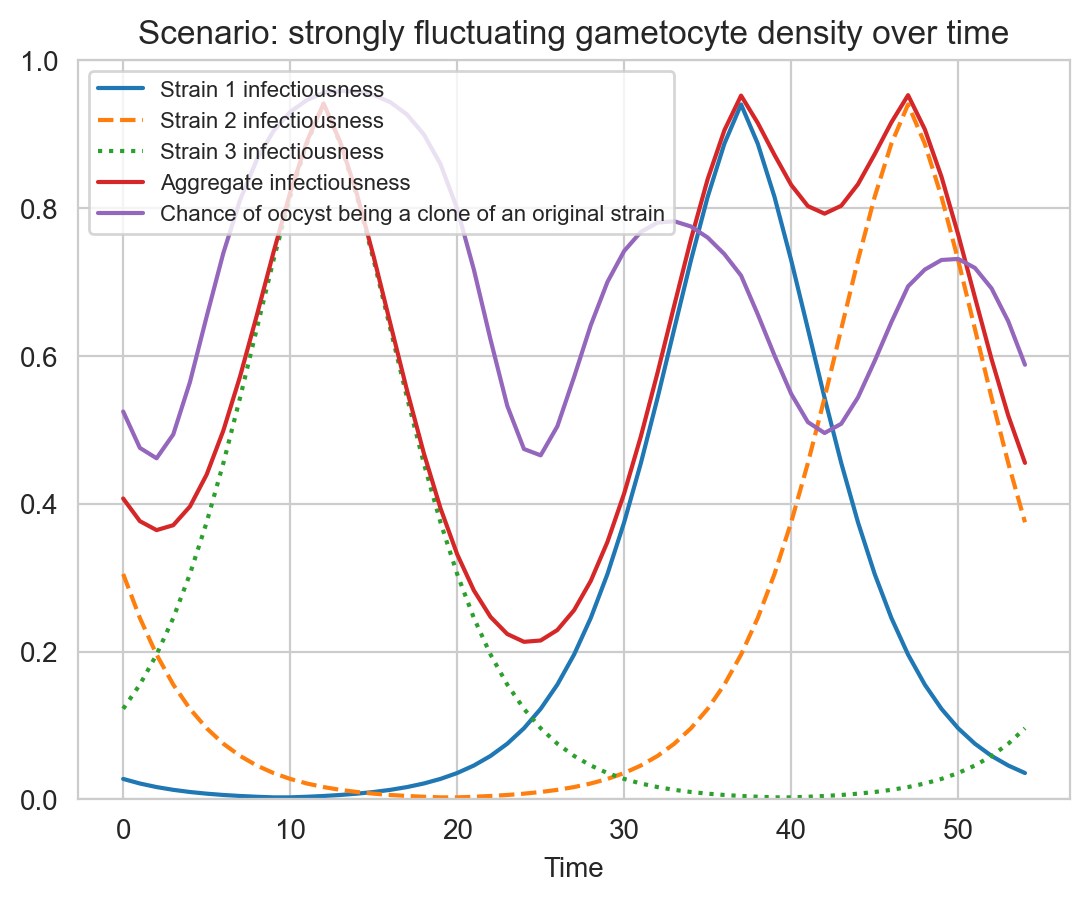

In [43]:
baseline_g_density = 1e9
n_timesteps = 55
ti = np.zeros(n_timesteps)
s1 = np.zeros(n_timesteps)
s2 = np.zeros(n_timesteps)
s3 = np.zeros(n_timesteps)
wc = np.zeros(n_timesteps)

# s1_modulator = np.roll(sawtooth, np.random.randint(55))
s1_modulator = np.roll(sawtooth, 10)
# s2_modulator = np.roll(sawtooth, np.random.randint(55))
s2_modulator = np.roll(sawtooth, 20)
# s3_modulator = np.roll(sawtooth, np.random.randint(55))
s3_modulator = np.roll(sawtooth, 40)

for t in np.arange(n_timesteps):
    s1[t] = infectiousness_from_gametocytes(baseline_g_density*s1_modulator[t], 20)
    s2[t] = infectiousness_from_gametocytes(baseline_g_density*s2_modulator[t], 20)
    s3[t] = infectiousness_from_gametocytes(baseline_g_density*s3_modulator[t], 20)
    ti[t] = 1-np.prod([1-s1[t], 1-s2[t], 1-s3[t]])
    # wc[t] = average_was_oocyst_clonal_result(1000, s1[t], s2[t], s3[t], 0)
    wc[t] = oocyst_clonal_exact(s1[t], s2[t], s3[t], 0)

plt.figure(dpi=200)
plt.plot(np.arange(n_timesteps), s1, label="Strain 1 infectiousness")
plt.plot(np.arange(n_timesteps), s2, label="Strain 2 infectiousness", linestyle='dashed')
plt.plot(np.arange(n_timesteps), s3, label="Strain 3 infectiousness", linestyle='dotted')
plt.plot(np.arange(n_timesteps), ti, label="Aggregate infectiousness")
plt.plot(np.arange(n_timesteps), wc, label="Chance of oocyst being a clone of an original strain")

plt.xlabel("Time")
plt.legend(fontsize=8)
plt.title("Scenario: strongly fluctuating gametocyte density over time")
plt.ylim([0,1])

print(np.mean(ti))

In [47]:
sawtooth.round(2)

array([0.01, 0.01, 0.01, 0.02, 0.02, 0.03, 0.03, 0.04, 0.05, 0.07, 0.09,
       0.12, 0.15, 0.19, 0.25, 0.33, 0.42, 0.54, 0.7 , 0.9 , 1.17, 1.51,
       1.95, 2.52, 3.25, 4.2 , 5.42, 7.  , 5.42, 4.2 , 3.25, 2.52, 1.95,
       1.51, 1.17, 0.9 , 0.7 , 0.54, 0.42, 0.33, 0.25, 0.19, 0.15, 0.12,
       0.09, 0.07, 0.05, 0.04, 0.03, 0.03, 0.02, 0.02, 0.01, 0.01, 0.01])

In [11]:
infectiousness_from_gametocytes(2*10**7.67,10)

0.06612413662181815

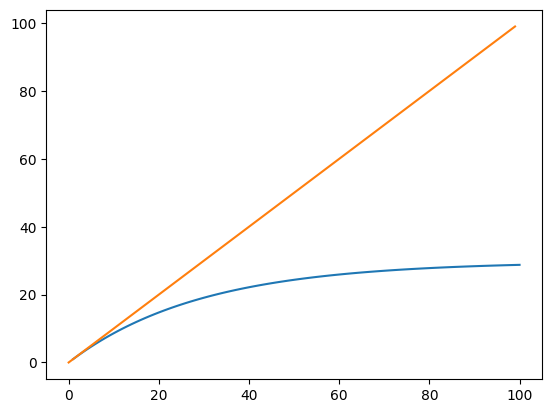

In [14]:
g_factor = np.empty(100)
inf_factor = np.empty(100)
for i in np.arange(100):
    g_factor[i] = i+1
    inf_factor[i] = infectiousness_from_gametocytes((i+1)*10**7.67,10)/infectiousness_from_gametocytes(10**7.67,10)
plt.plot(g_factor, inf_factor)
plt.plot(np.arange(100), np.arange(100))

In [15]:
base_gametocyte_mosquito_survival = 0.002011099
def infectiousness_from_gametocyte_density(g):
    return expcdf(g*base_gametocyte_mosquito_survival)

In [18]:
infectiousness_from_gametocyte_density(40)

0.07729338938662911

In [19]:
infectiousness_from_gametocyte_density(40*10)

0.5526614551499135

In [22]:
infectiousness_from_gametocyte_density(15)

0.0297160176278477

In [28]:
infectiousness_from_gametocyte_density(60)

0.1136700024581172

In [29]:
1-(1-0.0297160176278477)**4

0.1136700024581172

In [27]:
infectiousness_from_gametocyte_density(10)

0.019910112906792454

In [30]:
infectiousness_from_gametocyte_density(10*20)

0.33116628011882765

In [31]:
20*0.02

0.4